In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as pyplot
%matplotlib inline

import seaborn as sns
import plotly.express as px

In [4]:
df = pd.read_csv("../../data/Travel.csv")
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [ ]:
"""

cleaning the data:

1) managing null values
2) handling duplicates

"""

In [6]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [7]:
df["Gender"].value_counts()

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

In [8]:
df["MaritalStatus"].value_counts()

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

In [9]:
df['TypeofContact'].value_counts()

TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64

In [10]:
df["Gender"] = df["Gender"].replace("Fe Male", "Female")
df["MaritalStatus"] = df["MaritalStatus"].replace("Single", "Unmarried")

In [11]:
df["Gender"].value_counts()

Gender
Male      2916
Female    1972
Name: count, dtype: int64

In [12]:
df["MaritalStatus"].value_counts()

MaritalStatus
Married      2340
Unmarried    1598
Divorced      950
Name: count, dtype: int64

In [13]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [14]:
# checking missing values

features_with_na = [feature for feature in df.columns if df[feature].isnull().sum() >= 1]

for feature in features_with_na:
    print(np.round(df[feature].isnull().mean() * 100, 5), "% values are missing in: ", feature)

4.62357 % values are missing in:  Age
0.51146 % values are missing in:  TypeofContact
5.13502 % values are missing in:  DurationOfPitch
0.92062 % values are missing in:  NumberOfFollowups
0.53191 % values are missing in:  PreferredPropertyStar
2.86416 % values are missing in:  NumberOfTrips
1.35025 % values are missing in:  NumberOfChildrenVisiting
4.76678 % values are missing in:  MonthlyIncome


In [15]:
# description of the columns with null values

df[features_with_na].select_dtypes(exclude="object").describe()

,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


In [ ]:
"""

Imputation of Null Values

1) median   -   age
2) mode     -   type of contract
3) median   -   duration of pitch
4) mode     -   number of followups as it is a discrete feature
5) median   -   preferred propery star
6) median   -   number of trips
7) mode     -   number of childern visiting
8) median   -   monthly income

"""

In [17]:
df["Age"] = df["Age"].fillna(df["Age"].median())

df["TypeofContact"] = df["TypeofContact"].fillna(df["TypeofContact"].mode()[0])

df["DurationOfPitch"] = df["DurationOfPitch"].fillna(df["DurationOfPitch"].median())

df["NumberOfFollowups"] = df["NumberOfFollowups"].fillna(df["NumberOfFollowups"].mode()[0])

df["PreferredPropertyStar"] = df["PreferredPropertyStar"].fillna(df["PreferredPropertyStar"].mode()[0])

df["NumberOfTrips"] = df["NumberOfTrips"].fillna(df["NumberOfTrips"].median())

df["NumberOfChildrenVisiting"] = df["NumberOfChildrenVisiting"].fillna(df["NumberOfChildrenVisiting"].mode()[0])

df["MonthlyIncome"] = df["MonthlyIncome"].fillna(df["MonthlyIncome"].median())

In [18]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [19]:
df.isnull().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [20]:
df.drop(columns=["CustomerID"], inplace=True)

In [21]:
# feature engineering

In [22]:
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ProdTaken                 4888 non-null   int64  
 1   Age                       4888 non-null   float64
 2   TypeofContact             4888 non-null   str    
 3   CityTier                  4888 non-null   int64  
 4   DurationOfPitch           4888 non-null   float64
 5   Occupation                4888 non-null   str    
 6   Gender                    4888 non-null   str    
 7   NumberOfPersonVisiting    4888 non-null   int64  
 8   NumberOfFollowups         4888 non-null   float64
 9   ProductPitched            4888 non-null   str    
 10  PreferredPropertyStar     4888 non-null   float64
 11  MaritalStatus             4888 non-null   str    
 12  NumberOfTrips             4888 non-null   float64
 13  Passport                  4888 non-null   int64  
 14  PitchSatisfactionSc

In [23]:
# feature extraction

df["TotalVisiting"] = df["NumberOfPersonVisiting"] + df["NumberOfChildrenVisiting"]
df.drop(columns=["NumberOfPersonVisiting", "NumberOfChildrenVisiting"], inplace=True)

In [24]:
# getting all numeric features

num_features = [feature for feature in df.columns if df[feature].dtype in ["float64", "int64"]]

print("Count of numerical features:", len(num_features))

# print(num_features)

Count of numerical features: 12


In [26]:
# getting all categorical features

cat_features = [feature for feature in df.columns if df[feature].dtype == "str"]

print("Count of categorical features:", len(cat_features))

Count of categorical features: 6


In [27]:
# discrete features

discrete_features = [feature for feature in num_features if len(df[feature].unique()) <= 25]
print("Count of discrete features:", len(discrete_features))

Count of discrete features: 9


In [28]:
# continuous features

continuous_features = [feature for feature in num_features if feature not in discrete_features]
print("Count of continuous features:", len(continuous_features))

Count of continuous features: 3


In [29]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [30]:
# train test split

from sklearn.model_selection import train_test_split

x = df.drop(["ProdTaken"], axis=1)
y = df["ProdTaken"]

In [31]:
x.head()

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [32]:
y.value_counts()

ProdTaken
0    3968
1     920
Name: count, dtype: int64

In [33]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [34]:
x_train.shape, x_test.shape

((3910, 17), (978, 17))

In [35]:
x.info()

<class 'pandas.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     4888 non-null   float64
 1   TypeofContact           4888 non-null   str    
 2   CityTier                4888 non-null   int64  
 3   DurationOfPitch         4888 non-null   float64
 4   Occupation              4888 non-null   str    
 5   Gender                  4888 non-null   str    
 6   NumberOfFollowups       4888 non-null   float64
 7   ProductPitched          4888 non-null   str    
 8   PreferredPropertyStar   4888 non-null   float64
 9   MaritalStatus           4888 non-null   str    
 10  NumberOfTrips           4888 non-null   float64
 11  Passport                4888 non-null   int64  
 12  PitchSatisfactionScore  4888 non-null   int64  
 13  OwnCar                  4888 non-null   int64  
 14  Designation             4888 non-null   str    
 15

In [36]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

cat_features = x.select_dtypes(include=["object", "str"]).columns
num_features = x.select_dtypes(include=["int64", "float64"]).columns

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder(drop="first")

preprocessor = ColumnTransformer(
    transformers=[
        ("OneHotEncoder", oh_transformer, cat_features),
        ("StandardScaler", numeric_transformer, num_features)
    ]
)

cat_features

Index(['TypeofContact', 'Occupation', 'Gender', 'ProductPitched',
       'MaritalStatus', 'Designation'],
      dtype='str')

In [37]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('OneHotEncoder', ...), ('StandardScaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``f

In [38]:
x_train = preprocessor.fit_transform(x_train)

In [39]:
pd.DataFrame(x_train)

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,-1.020350,1.284279,-0.725271,-0.127737,-0.632399,0.679690,0.782966,-0.382245,-0.774151
1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,-0.721400,0.690023,0.282777,-0.725271,1.511598,-0.632399,0.679690,0.782966,-0.459799,0.643615
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,-1.020350,0.282777,1.771041,0.418708,-0.632399,0.679690,0.782966,-0.245196,-0.065268
3,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,-0.721400,-1.020350,1.284279,-0.725271,-0.127737,-0.632399,1.408395,-1.277194,0.213475,-0.065268
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,2.400396,-1.720227,-0.725271,1.511598,-0.632399,-0.049015,-1.277194,-0.024889,2.061382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3905,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,-0.653841,1.284279,-0.725271,-0.674182,-0.632399,-1.506426,0.782966,-0.536973,0.643615
3906,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.455047,-0.898180,-0.718725,1.771041,-1.220627,-0.632399,1.408395,0.782966,1.529609,-0.065268
3907,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.455047,1.545210,0.282777,-0.725271,2.058043,-0.632399,-0.777720,0.782966,-0.360576,0.643615
3908,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.455047,1.789549,1.284279,-0.725271,-0.127737,-0.632399,-1.506426,0.782966,-0.252799,0.643615


In [40]:
x_test = preprocessor.transform(x_test)

In [41]:
x_test

array([[ 0.        ,  0.        ,  0.        , ..., -1.2771941 ,
        -0.73751038, -0.77415132],
       [ 1.        ,  0.        ,  0.        , ..., -1.2771941 ,
        -0.6704111 , -0.06526803],
       [ 1.        ,  0.        ,  0.        , ...,  0.78296635,
        -0.4208322 , -0.77415132],
       ...,
       [ 0.        ,  1.        ,  0.        , ...,  0.78296635,
         0.69001249,  0.64361526],
       [ 1.        ,  0.        ,  0.        , ...,  0.78296635,
        -0.22827818, -0.77415132],
       [ 1.        ,  1.        ,  0.        , ...,  0.78296635,
        -0.44611323,  2.06138184]], shape=(978, 26))

In [42]:
# model training

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

In [43]:
models = {
    "Logisitic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boost": GradientBoostingClassifier(),
    "Adaboost": AdaBoostClassifier()
}

In [44]:

for i in range(len(list(models))):

    model = list(models.values())[i]

    model.fit(x_train, y_train)

    y_train_pred = model.predict(x_train)
    y_test_pred  = model.predict(x_test)

    # performance on training data

    model_train_accuracy        = accuracy_score(y_train, y_train_pred)
    model_train_f1              = f1_score(y_train, y_train_pred, average="weighted")
    model_train_precision       = precision_score(y_train, y_train_pred)
    model_train_recall          = recall_score(y_train, y_train_pred)
    model_train_rocauc_score    = roc_auc_score(y_train, y_train_pred)

    # performance on testing  data

    model_test_accuracy        = accuracy_score(y_test, y_test_pred)
    model_test_f1              = f1_score(y_test, y_test_pred, average="weighted")
    model_test_precision       = precision_score(y_test, y_test_pred)
    model_test_recall          = recall_score(y_test, y_test_pred)
    model_test_rocauc_score    = roc_auc_score(y_test, y_test_pred)

    print("\n", list(models.keys())[i])

    print("\nModel Performance on Training Set:")
    print("\tAccuracy: \t\t\t", {model_train_accuracy})
    print("\tF1 Score: \t\t\t", {model_train_f1})
    print("\tPrecision: \t\t\t", {model_train_precision})
    print("\tRecall: \t\t\t", {model_train_recall})
    print("\tROC AUC Score: \t\t\t", {model_train_rocauc_score})

    print("\nModel Performance on Testing Set:")
    print("\tAccuracy: \t\t\t", {model_test_accuracy})
    print("\tF1 Score: \t\t\t", {model_test_f1})
    print("\tPrecision: \t\t\t", {model_test_precision})
    print("\tRecall: \t\t\t", {model_test_recall})
    print("\tROC AUC Score: \t\t\t", {model_test_rocauc_score})



 Logisitic Regression

Model Performance on Training Set:
	Accuracy: 			 {0.8460358056265984}
	F1 Score: 			 {0.8202118738880438}
	Precision: 			 {0.7015873015873015}
	Recall: 			 {0.30315500685871055}
	ROC AUC Score: 			 {0.6368022755136056}

Model Performance on Testing Set:
	Accuracy: 			 {0.83640081799591}
	F1 Score: 			 {0.8086633047343356}
	Precision: 			 {0.691358024691358}
	Recall: 			 {0.2931937172774869}
	ROC AUC Score: 			 {0.630713758257549}

 Decision Tree

Model Performance on Training Set:
	Accuracy: 			 {1.0}
	F1 Score: 			 {1.0}
	Precision: 			 {1.0}
	Recall: 			 {1.0}
	ROC AUC Score: 			 {1.0}

Model Performance on Testing Set:
	Accuracy: 			 {0.9202453987730062}
	F1 Score: 			 {0.9197604916567391}
	Precision: 			 {0.8054054054054054}
	Recall: 			 {0.7801047120418848}
	ROC AUC Score: 			 {0.8671806914720225}

 Random Forest

Model Performance on Training Set:
	Accuracy: 			 {0.9997442455242966}
	F1 Score: 			 {0.9997441778538075}
	Precision: 			 {1.0}
	Recall: 			 {0

In [54]:
# hyperparameter tuning

rf_params = {
    "max_depth": [5, 8, 15, None, 10],
    "max_features": [5, 7, "auto", 8],
    "min_samples_split": [2, 8, 15, 20],
    "n_estimators": [100, 200, 500, 1000],
}

adaboost_params = {
    "n_estimators" : [50, 60, 70, 80, 90],
    # "algorithm" : ["SAMME", "SAMME.R"]              this parameter has already been deprecated
}

In [55]:
rf_params

{'max_depth': [5, 8, 15, None, 10],
 'max_features': [5, 7, 'auto', 8],
 'min_samples_split': [2, 8, 15, 20],
 'n_estimators': [100, 200, 500, 1000]}

In [56]:
adaboost_params

{'n_estimators': [50, 60, 70, 80, 90]}

In [57]:
# models list for hyperparameter tuning

randomCV_models = [
    ("RF", RandomForestClassifier(), rf_params),
    ("AB", AdaBoostClassifier(), adaboost_params),
]

In [58]:
from sklearn.model_selection import RandomizedSearchCV

model_params = {}

for name, model, params in randomCV_models:

    random = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=100,
        cv=3,
        verbose=2,
        n_jobs=-1,
    )

    random.fit(x_train, y_train)
    model_params[name] = random.best_params_

for model_name in model_params:

    print(f"Best Params for {model_name}:")
    print(model_params[model_name], "\n")

Fitting 3 folds for each of 100 candidates, totalling 300 fits


c:\Users\Bhargav Ram\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
69 fits failed out of a total of 300.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
43 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Bhargav Ram\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Bhargav Ram\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Params for RF:
{'n_estimators': 500, 'min_samples_split': 2, 'max_features': 8, 'max_depth': None} 

Best Params for AB:
{'n_estimators': 80} 



In [59]:
models = {
    
    "Random Forest": RandomForestClassifier(
        n_estimators=1000,
        min_samples_split=2,
        max_features=8,max_depth=15,
    ),

    "Adaboost": AdaBoostClassifier(
        n_estimators=80
    )

}

In [60]:

for i in range(len(list(models))):

    model = list(models.values())[i]

    model.fit(x_train, y_train)

    y_train_pred = model.predict(x_train)
    y_test_pred  = model.predict(x_test)

    # performance on training data

    model_train_accuracy        = accuracy_score(y_train, y_train_pred)
    model_train_f1              = f1_score(y_train, y_train_pred, average="weighted")
    model_train_precision       = precision_score(y_train, y_train_pred)
    model_train_recall          = recall_score(y_train, y_train_pred)
    model_train_rocauc_score    = roc_auc_score(y_train, y_train_pred)

    # performance on testing  data

    model_test_accuracy        = accuracy_score(y_test, y_test_pred)
    model_test_f1              = f1_score(y_test, y_test_pred, average="weighted")
    model_test_precision       = precision_score(y_test, y_test_pred)
    model_test_recall          = recall_score(y_test, y_test_pred)
    model_test_rocauc_score    = roc_auc_score(y_test, y_test_pred)

    print("\n", list(models.keys())[i])

    print("\nModel Performance on Training Set:")
    print("\tAccuracy: \t\t\t", {model_train_accuracy})
    print("\tF1 Score: \t\t\t", {model_train_f1})
    print("\tPrecision: \t\t\t", {model_train_precision})
    print("\tRecall: \t\t\t", {model_train_recall})
    print("\tROC AUC Score: \t\t\t", {model_train_rocauc_score})

    print("\nModel Performance on Testing Set:")
    print("\tAccuracy: \t\t\t", {model_test_accuracy})
    print("\tF1 Score: \t\t\t", {model_test_f1})
    print("\tPrecision: \t\t\t", {model_test_precision})
    print("\tRecall: \t\t\t", {model_test_recall})
    print("\tROC AUC Score: \t\t\t", {model_test_rocauc_score})



 Random Forest

Model Performance on Training Set:
	Accuracy: 			 {0.99923273657289}
	F1 Score: 			 {0.9992321263958706}
	Precision: 			 {1.0}
	Recall: 			 {0.9958847736625515}
	ROC AUC Score: 			 {0.9979423868312758}

Model Performance on Testing Set:
	Accuracy: 			 {0.9304703476482618}
	F1 Score: 			 {0.9252689839320366}
	Precision: 			 {0.9694656488549618}
	Recall: 			 {0.6649214659685864}
	ROC AUC Score: 			 {0.8299194369233022}

 Adaboost

Model Performance on Training Set:
	Accuracy: 			 {0.8465473145780051}
	F1 Score: 			 {0.8131954184297732}
	Precision: 			 {0.7698744769874477}
	Recall: 			 {0.252400548696845}
	ROC AUC Score: 			 {0.6175551941849519}

Model Performance on Testing Set:
	Accuracy: 			 {0.83640081799591}
	F1 Score: 			 {0.797683978346618}
	Precision: 			 {0.7818181818181819}
	Recall: 			 {0.225130890052356}
	ROC AUC Score: 			 {0.6049415568432047}


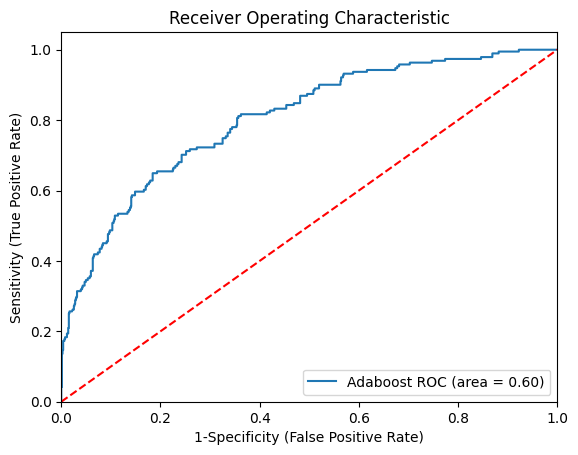

In [61]:
# plotting ROC AUC Curve

import matplotlib.pyplot as plt

plt.figure()

auc_models = [

{
    "label": "Adaboost",
    "model": AdaBoostClassifier(
        n_estimators=80,
    ),
    "auc": 0.604
},

]

for algo in auc_models:

    model = algo["model"]
    
    model.fit(x_train, y_train)

    fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(x_test)[:, 1])

    plt.plot(fpr, tpr, label="%s ROC (area = %0.2f)" % (algo["label"], algo["auc"]))

plt.plot([0, 1], [0, 1], 'r--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel('1-Specificity (False Positive Rate)')
plt.ylabel('Sensitivity (True Positive Rate)')

plt.title('Receiver Operating Characteristic')

plt.legend(loc="lower right")
plt.savefig("auc.png")

plt.show() 